# Pharmacies, clinics and hospitals in Punjab (Pakistan): map and population density within 500 m

Same workflow as `pharmacies_punjab_density.ipynb`, extended to three facility categories:
1. Map all pharmacies, clinics and hospitals in Punjab (healthsites.io data, GADM boundaries, Degree of Urbanisation background) and export a 400 dpi JPEG.
2. Estimate population density (inhabitants/hectare) in a 500 m buffer around each facility (WorldPop 100 m population counts) and plot histograms (20 bins) **separately for the three categories**, with Q1, median and Q3 lines, exported as a 400 dpi JPEG.
3. Export facilities and buffers to a GeoPackage.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW, TEMP, OUT = ROOT / "data/raw", ROOT / "data/temp", ROOT / "data/output"
for d in (RAW, TEMP, OUT):
    d.mkdir(parents=True, exist_ok=True)

BUFFER_M = 500
WORKING_CRS = "EPSG:32643"   # WGS 84 / UTM 43N, metric CRS used for buffering and areas
DPI = 400

CATEGORIES = ["pharmacy", "clinic", "hospital"]

# Hospital refinement: tag-based hospitals are kept as hospitals only if their name contains one of these keywords
# (English incl. common misspellings, Urdu, Pashto, and the THQ/DHQ/CMH acronyms); the others become "other clinic"
HOSPITAL_PATTERN = r"hospital|hospitl|haspital|ہسپتال|اسپتال|روغتون|(?:thq|dhq|cmh)"
# Points of the same category closer than this distance (metres) are merged into one
MERGE_DIST_M = {"pharmacy": 50, "clinic": 50, "hospital": 250}
CAT_STYLE = {   # colour and marker per category (shapes differ so the map also reads without colour)
    "pharmacy": dict(color="#1f3b73", marker="o", label="Pharmacy"),
    "clinic":   dict(color="#1b8a7a", marker="s", label="Clinic"),
    "hospital": dict(color="#b5179e", marker="^", label="Hospital"),
}

HS_DIR = RAW / "health-sites-io"   # manual download from healthsites.io (OSM extract: Pakistan-node.shp, Pakistan-way.shp)

# Local inputs, all read from data/raw/ (download them beforehand, see README for the sources)
RAW_FILES = {
    "GADM 4.1 boundaries": RAW / "gadm41_PAK.gpkg",
    "WorldPop population 100 m (2025)": RAW / "pak_pop_2025_CN_100m_R2025A_v1.tif",
    "Degree of Urbanisation L1 (2025)": RAW / "PAK_DUG_2025_GRID_L1_R2025A_v1.tif",
    "healthsites.io nodes": HS_DIR / "Pakistan-node.shp",
    "healthsites.io ways": HS_DIR / "Pakistan-way.shp",
}
DUG_CLASSES = {1: "Rural", 2: "Towns and suburbs (urban cluster)", 3: "Cities (urban centre)"}

## 0. Check raw inputs

All inputs are read from `data/raw/` (no download is done by the notebook).

In [2]:
missing = {k: v for k, v in RAW_FILES.items() if not v.exists() or v.stat().st_size == 0}
assert not missing, "Missing raw files in data/raw/:\n" + "\n".join(f"  {k}: {v}" for k, v in missing.items())
for k, v in RAW_FILES.items():
    print(f"found  {k}: {v.relative_to(ROOT)}")

found  GADM 4.1 boundaries: data/raw/gadm41_PAK.gpkg
found  WorldPop population 100 m (2025): data/raw/pak_pop_2025_CN_100m_R2025A_v1.tif
found  Degree of Urbanisation L1 (2025): data/raw/PAK_DUG_2025_GRID_L1_R2025A_v1.tif
found  healthsites.io nodes: data/raw/health-sites-io/Pakistan-node.shp
found  healthsites.io ways: data/raw/health-sites-io/Pakistan-way.shp


## 1. Punjab boundary and health facilities

In [3]:
adm1 = gpd.read_file(RAW / "gadm41_PAK.gpkg", layer="ADM_ADM_1")
punjab = adm1[adm1["NAME_1"] == "Punjab"].to_crs(4326)
adm2 = gpd.read_file(RAW / "gadm41_PAK.gpkg", layer="ADM_ADM_2").to_crs(4326)
punjab_districts = adm2[adm2["NAME_1"] == "Punjab"]

# healthsites.io extract: points (OSM nodes) and building polygons (OSM ways)
# Shapefile field names are truncated to 10 characters (some collide), so only the needed fields are kept
HS_COLS = ["osm_id", "amenity", "healthcare", "name", "operator", "operator_t", "addr_stree", "addr_city", "geometry"]
hs = pd.concat([
    gpd.read_file(HS_DIR / "Pakistan-node.shp")[HS_COLS].assign(osm_type="node"),
    gpd.read_file(HS_DIR / "Pakistan-way.shp")[HS_COLS].assign(osm_type="way"),
], ignore_index=True)
hs = gpd.GeoDataFrame(hs, geometry="geometry", crs=4326)
print("all healthsites:", len(hs))

all healthsites: 4954


In [4]:
# Category = pharmacy / clinic / hospital, from amenity or healthcare tags.
# A site tagged with more than one category (e.g. amenity=clinic + healthcare=hospital) is counted once,
# with priority hospital > clinic > pharmacy.
tagged = {c: (hs["amenity"] == c) | (hs["healthcare"] == c) for c in CATEGORIES}
n_tags = sum(t.astype(int) for t in tagged.values())
print("sites matching more than one category:", int((n_tags > 1).sum()))

hs["category"] = None
for c in CATEGORIES:                       # later assignments (higher priority) overwrite earlier ones
    hs.loc[tagged[c], "category"] = c
fac = hs[hs["category"].notna()].copy()
print(fac["category"].value_counts().to_dict(), "(Pakistan)")

sites matching more than one category: 0
{'hospital': 2492, 'clinic': 920, 'pharmacy': 874} (Pakistan)


In [5]:
# Quality checks: geometry type, missing/duplicate records
print(fac.groupby("category").apply(lambda g: g.geom_type.value_counts().to_dict(), include_groups=False).to_dict())
print("empty geometries:", fac.geometry.is_empty.sum())
print("duplicate osm_type+osm_id:", fac.duplicated(["osm_type", "osm_id"]).sum())

{'clinic': {'Point': 855, 'Polygon': 65}, 'hospital': {'Point': 1989, 'Polygon': 503}, 'pharmacy': {'Point': 834, 'Polygon': 40}}
empty geometries: 0
duplicate osm_type+osm_id: 0


In [6]:
# Non-point features (facilities mapped as building polygons) are represented by their centroid
fac = fac[~fac.geometry.is_empty].copy()
fac["geometry"] = fac.to_crs(WORKING_CRS).centroid.to_crs(4326).where(~fac.geom_type.eq("Point"), fac.geometry)
fac = fac.drop_duplicates(["osm_type", "osm_id"])

# Summary of facility counts after each processing step (saved at the end)
steps = {}
def record(label, d):
    n = d["category"].value_counts().reindex(CATEGORIES).fillna(0).astype(int)
    steps[label] = {**n.to_dict(), "total": int(n.sum()), "of which other clinic": int((d["subtype"] == "other clinic").sum()) if "subtype" in d else 0}
record("1. Tagged in healthsites.io, all Pakistan", fac)

# Keep facilities falling inside Punjab (spatial filter on the GADM polygon)
fac = gpd.sjoin(fac, punjab[["NAME_1", "geometry"]], how="inner", predicate="within").drop(columns=["index_right"])
fac = fac.rename(columns={"NAME_1": "province"})
# District attribution (GADM level 2)
fac = gpd.sjoin(fac, punjab_districts[["NAME_2", "geometry"]], how="left", predicate="within").drop(columns=["index_right"])
fac = fac.rename(columns={"NAME_2": "district"}).reset_index(drop=True)
record("2. Inside Punjab", fac)

### Hospital refinement and merging of nearby points

Hospitals are tagged loosely in OpenStreetMap (labs, dental clinics, herbal practitioners, etc. appear as hospitals), and a single facility is often mapped several times (building polygon, entrances, wards).
1. **Hospital name filter.** Hospital-tagged sites whose name does not contain a hospital keyword (or that have no name) are reclassified as clinics, with `subtype = "other clinic"`. Genuine clinics keep `subtype = "clinic"`.
2. **Merging.** Within each category, points closer than a threshold are merged into one: 50 m for pharmacies and clinics, 250 m for hospitals (single linkage: chains of points each within the threshold of the next form one group). The merged point is the mean location of the group and takes the longest name; `n_merged` records how many points were merged. A merged clinic group is an "other clinic" only if all its members are.

In [7]:
from shapely.geometry import Point

fac["subtype"] = fac["category"]
is_hosp = fac["category"] == "hospital"
name_ok = fac["name"].fillna("").str.contains(HOSPITAL_PATTERN, case=False, regex=True)
print(f"hospitals before filter: {is_hosp.sum()} | with keyword in name: {(is_hosp & name_ok).sum()} | reclassified as other clinic: {(is_hosp & ~name_ok).sum()}")
fac.loc[is_hosp & ~name_ok, ["category", "subtype"]] = ["clinic", "other clinic"]
record("3. After hospital name filter (non-matching hospitals reclassified as other clinic)", fac)

def merge_close_points(gdf, dist_m):
    # Group points closer than dist_m: overlapping buffers of radius dist_m/2 <=> distance < dist_m
    g = gdf.to_crs(WORKING_CRS)
    blobs = gpd.GeoDataFrame(geometry=list(g.buffer(dist_m / 2).union_all().geoms), crs=WORKING_CRS)
    g["cluster"] = gpd.sjoin(g[["geometry"]], blobs, predicate="intersects")["index_right"]
    merged = []
    for _, grp in g.groupby("cluster"):
        rep = grp.assign(_len=grp["name"].fillna("").str.len()).sort_values("_len", ascending=False).iloc[0].drop("_len")
        rep["geometry"] = Point(grp.geometry.x.mean(), grp.geometry.y.mean())
        rep["n_merged"] = len(grp)
        if (grp["subtype"] == "clinic").any():
            rep["subtype"] = "clinic"
        merged.append(rep)
    return gpd.GeoDataFrame(merged, geometry="geometry", crs=WORKING_CRS).drop(columns="cluster").to_crs(4326)

fac = pd.concat([merge_close_points(fac[fac["category"] == c], MERGE_DIST_M[c]) for c in CATEGORIES], ignore_index=True)
record("4. After merging nearby points (final)", fac)
print("largest merged group:", fac.groupby("category")["n_merged"].max().to_dict())

hospitals before filter: 825 | with keyword in name: 531 | reclassified as other clinic: 294


largest merged group: {'clinic': 3, 'hospital': 4, 'pharmacy': 9}


In [8]:
fac["facility_id"] = np.arange(1, len(fac) + 1)
fac.to_file(TEMP / "health_facilities_punjab.gpkg", layer="facilities", driver="GPKG")

summary = pd.DataFrame(steps).T
summary.to_csv(OUT / "facility_counts_by_step.csv")
print("facilities in Punjab:", len(fac))
summary

facilities in Punjab: 1105


,pharmacy,clinic,hospital,total,of which other clinic
"1. Tagged in healthsites.io, all Pakistan",874,920,2492,4286,0
2. Inside Punjab,242,195,825,1262,0
3. After hospital name filter (non-matching hospitals reclassified as other clinic),242,489,531,1262,294
4. After merging nearby points (final),198,460,447,1105,272


### 1bis. Map of pharmacies, clinics and hospitals on the Degree of Urbanisation (JPEG, 400 dpi)

The 1 km Degree of Urbanisation grid (Mollweide) is reprojected to WGS 84 with nearest-neighbour resampling, clipped to Punjab and used as background.

In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.patheffects as pe
from rasterio.features import geometry_mask
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling

# Reproject DUG L1 (ESRI:54009) onto a regular lon/lat grid covering Punjab
minx, miny, maxx, maxy = punjab.total_bounds
res = 0.005
w, h = int(np.ceil((maxx - minx) / res)), int(np.ceil((maxy - miny) / res))
dst_transform = from_origin(minx, maxy, res, res)
dug = np.zeros((h, w), dtype="uint8")
with rasterio.open(RAW / "PAK_DUG_2025_GRID_L1_R2025A_v1.tif") as src:
    reproject(rasterio.band(src, 1), dug, dst_transform=dst_transform, dst_crs="EPSG:4326", resampling=Resampling.nearest)
outside = geometry_mask(punjab.geometry, out_shape=dug.shape, transform=dst_transform, invert=False)
dug = np.ma.masked_where(outside | (dug == 0), dug)
print({DUG_CLASSES[k]: int((dug == k).sum()) for k in DUG_CLASSES}, "(pixels)")

{'Rural': 462564, 'Towns and suburbs (urban cluster)': 285115, 'Cities (urban centre)': 25213} (pixels)


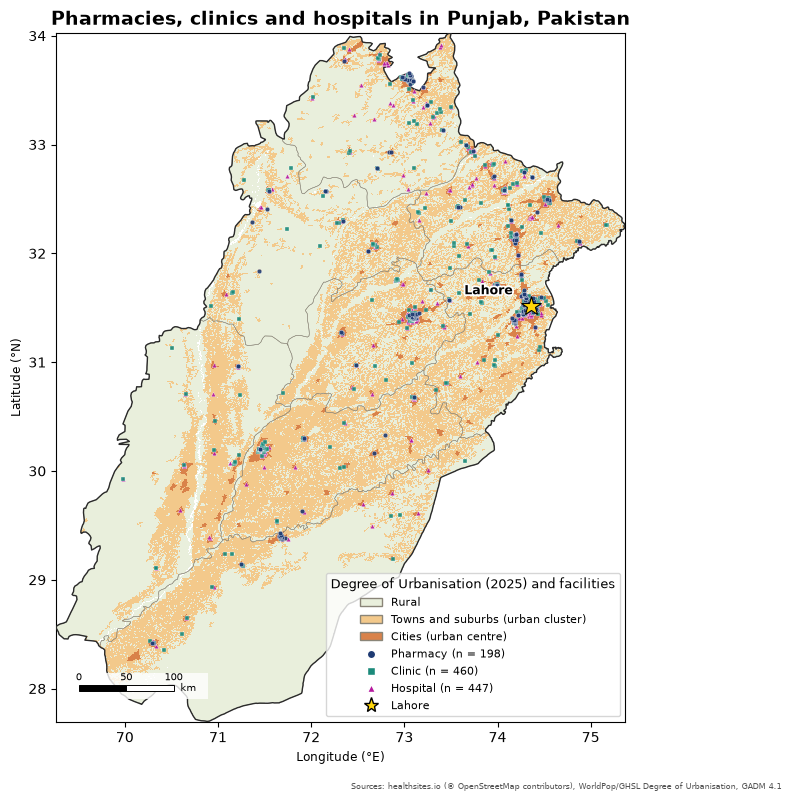

In [10]:
LAHORE = (74.3587, 31.5204)   # lon, lat of Lahore city centre
dug_colors = {1: "#e9efdc", 2: "#f3c98b", 3: "#d9824a"}
cmap = ListedColormap([dug_colors[k] for k in (1, 2, 3)])
extent = (minx, minx + w * res, maxy - h * res, maxy)

def add_scale_bar(ax, length_km=100, n_seg=2, x_frac=0.04, y_frac=0.045, height_frac=0.008):
    # Alternating black/white scale bar in km, bottom-left of a lon/lat axes.
    # Length is exact at the latitude where the bar is drawn (1 deg lon = 111.32 km * cos(lat)).
    x0_ax, x1_ax = ax.get_xlim(); y0_ax, y1_ax = ax.get_ylim()
    x0, y0 = x0_ax + x_frac * (x1_ax - x0_ax), y0_ax + y_frac * (y1_ax - y0_ax)
    deg_per_km = 1 / (111.32 * np.cos(np.radians(y0)))
    seg = length_km / n_seg
    hgt = height_frac * (y1_ax - y0_ax)
    pad_x, pad_y = 0.015 * (x1_ax - x0_ax), 0.012 * (y1_ax - y0_ax)   # translucent white backing for legibility
    ax.add_patch(plt.Rectangle((x0 - pad_x, y0 - pad_y), length_km * deg_per_km + 5 * pad_x, hgt + 0.03 * (y1_ax - y0_ax),
                               facecolor="white", edgecolor="none", alpha=0.8, zorder=9))
    for i in range(n_seg):
        ax.add_patch(plt.Rectangle((x0 + i * seg * deg_per_km, y0), seg * deg_per_km, hgt, facecolor="black" if i % 2 == 0 else "white",
                                   edgecolor="black", linewidth=0.7, zorder=10))
    for i in range(n_seg + 1):
        ax.text(x0 + i * seg * deg_per_km, y0 + hgt + 0.004 * (y1_ax - y0_ax), f"{i * seg:g}", ha="center", va="bottom", fontsize=7, zorder=10)
    ax.text(x0 + length_km * deg_per_km + 0.012 * (x1_ax - x0_ax), y0 + hgt / 2, "km", ha="left", va="center", fontsize=7, zorder=10)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(dug, cmap=cmap, vmin=0.5, vmax=3.5, extent=extent, interpolation="nearest", zorder=1)
punjab_districts.boundary.plot(ax=ax, color="#8a8578", linewidth=0.35, zorder=2)
punjab.boundary.plot(ax=ax, color="#2b2b2b", linewidth=1.0, zorder=3)
for z, cat in enumerate(["hospital", "clinic", "pharmacy"], start=4):   # pharmacies drawn last (fewest)
    st = CAT_STYLE[cat]
    fac[fac.category == cat].plot(ax=ax, color=st["color"], marker=st["marker"], edgecolor="white", linewidth=0.25,
                                  markersize=11, alpha=0.9, zorder=z)
handles = [Patch(facecolor=dug_colors[k], edgecolor="#8a8578", label=DUG_CLASSES[k]) for k in (1, 2, 3)]
n_cat = fac["category"].value_counts()
for cat in CATEGORIES:
    st = CAT_STYLE[cat]
    handles.append(plt.Line2D([], [], marker=st["marker"], ls="", markerfacecolor=st["color"], markeredgecolor="white",
                              markersize=6, label=f"{st['label']} (n = {n_cat.get(cat, 0)})"))
handles.append(plt.Line2D([], [], marker="*", ls="", markerfacecolor="#ffd60a", markeredgecolor="black", markersize=11, label="Lahore"))
ax.legend(handles=handles, title="Degree of Urbanisation (2025) and facilities", loc="lower right", frameon=True, fontsize=8, title_fontsize=9)
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
add_scale_bar(ax, length_km=100)
ax.plot(*LAHORE, marker="*", ls="", markersize=15, markerfacecolor="#ffd60a", markeredgecolor="black", markeredgewidth=0.8, zorder=8)
ax.annotate("Lahore", LAHORE, xytext=(-12, 6), textcoords="offset points", ha="right", va="bottom", fontsize=9, weight="bold",
            zorder=8, path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
ax.set_title("Pharmacies, clinics and hospitals in Punjab, Pakistan", fontsize=14, weight="bold")
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
plt.tight_layout(rect=(0, 0.02, 1, 1))
fig.text(0.99, 0.005, "Sources: healthsites.io (© OpenStreetMap contributors), WorldPop/GHSL Degree of Urbanisation, GADM 4.1",
         ha="right", va="bottom", fontsize=6, color="#555")
fig.savefig(OUT / "map_health_facilities_punjab.jpeg", dpi=DPI, format="jpeg", pil_kwargs={"quality": 95})
plt.show()

## 2. Population density within 500 m of each facility

Buffers are built in a metric CRS (UTM 43N), then sent back to WGS 84 to sum WorldPop 100 m pixels (people per pixel) whose centre falls inside the buffer. Density = people in buffer / buffer area in hectares (1 ha = 10,000 m²).

In [11]:
fac_m = fac.to_crs(WORKING_CRS)
buffers = gpd.GeoDataFrame(fac_m[["facility_id", "category", "name", "district"]].copy(),
                           geometry=fac_m.geometry.buffer(BUFFER_M, quad_segs=32), crs=WORKING_CRS)
buffers["buffer_area_ha"] = buffers.geometry.area / 10_000
buffers = buffers.to_crs(4326)
print("buffer area (ha), min/max:", buffers.buffer_area_ha.min().round(2), buffers.buffer_area_ha.max().round(2))

buffer area (ha), min/max: 78.51 78.51


In [12]:
RASTER = RAW / "pak_pop_2025_CN_100m_R2025A_v1.tif"
pop_sum, n_pix = [], []
with rasterio.open(RASTER) as src:   # windowed read per buffer keeps memory low (the full raster is ~1.3 GB in memory)
    for geom in buffers.geometry:
        arr, _ = mask(src, [geom], crop=True, all_touched=False, nodata=src.nodata, filled=False)
        valid = arr.compressed()
        pop_sum.append(float(valid.sum()) if valid.size else 0.0)
        n_pix.append(int(valid.size))
buffers["pop_sum"] = pop_sum
buffers["n_pixels"] = n_pix
buffers["density_hab_ha"] = buffers["pop_sum"] / buffers["buffer_area_ha"]
buffers.drop(columns="geometry").to_csv(TEMP / "health_facility_density.csv", index=False)
buffers.groupby("category")["density_hab_ha"].describe().reindex(CATEGORIES).round(1)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
pharmacy,198.0,232.7,105.8,9.8,141.7,246.9,318.5,433.3
clinic,460.0,195.8,116.5,2.5,98.9,199.0,293.4,422.9
hospital,447.0,220.1,113.7,0.3,128.7,233.5,311.7,446.5


In [13]:
# Join density back to facility points
fac = fac.merge(buffers[["facility_id", "buffer_area_ha", "pop_sum", "n_pixels", "density_hab_ha"]], on="facility_id")
print("buffers with fewer than 60 valid pixels (edge/nodata):", (buffers.n_pixels < 60).sum())

buffers with fewer than 60 valid pixels (edge/nodata): 2


### 2bis. Histograms of population density by category (20 bins; Q1, median, Q3)

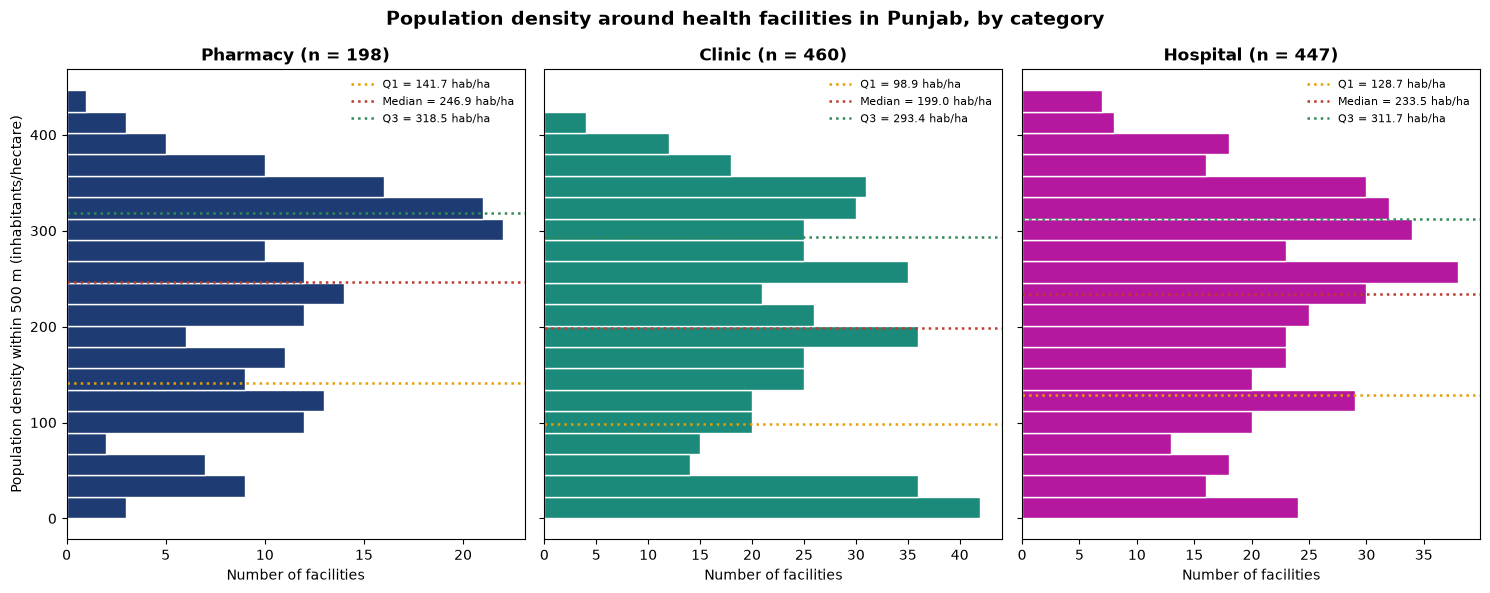

              Q1  median      Q3
category                        
pharmacy  141.72  246.87  318.47
clinic     98.91  198.98  293.39
hospital  128.68  233.50  311.72


In [14]:
# One panel per category, shared density axis and shared bin edges (20 bins over the overall range) so panels are comparable
bins = np.linspace(fac["density_hab_ha"].min(), fac["density_hab_ha"].max(), 21)
Q_STYLE = [(0.25, "Q1", "#e69f00"), (0.50, "Median", "#c0392b"), (0.75, "Q3", "#2e8b57")]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, cat in zip(axes, CATEGORIES):
    d = fac.loc[fac.category == cat, "density_hab_ha"]
    ax.hist(d, bins=bins, orientation="horizontal", color=CAT_STYLE[cat]["color"], edgecolor="white")
    for q, lab, c in Q_STYLE:
        ax.axhline(d.quantile(q), ls=":", lw=1.8, color=c, label=f"{lab} = {d.quantile(q):.1f} hab/ha")
    ax.set_title(f"{CAT_STYLE[cat]['label']} (n = {len(d)})", weight="bold")
    ax.set_xlabel("Number of facilities")
    ax.legend(frameon=False, loc="upper right", fontsize=8)
axes[0].set_ylabel("Population density within 500 m (inhabitants/hectare)")
fig.suptitle("Population density around health facilities in Punjab, by category", fontsize=14, weight="bold")
plt.tight_layout()
fig.savefig(OUT / "hist_density_health_facilities_punjab.jpeg", dpi=DPI, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print(fac.groupby("category")["density_hab_ha"].quantile([0.25, 0.5, 0.75]).unstack().reindex(CATEGORIES).round(2).rename(columns={0.25: "Q1", 0.5: "median", 0.75: "Q3"}))

> Bars are horizontal (density on the *y* axis), so the horizontal dotted lines mark Q1, median and Q3 directly on the density scale.

## 3. Export to GeoPackage

In [15]:
gpkg = OUT / "health_facilities_punjab_buffers.gpkg"
gpkg.unlink(missing_ok=True)
keep = ["facility_id", "category", "osm_type", "osm_id", "name", "subtype", "operator_t", "district", "province",
        "n_merged", "pop_sum", "buffer_area_ha", "density_hab_ha", "geometry"]
fac[keep].to_file(gpkg, layer="facilities", driver="GPKG")
buffers[["facility_id", "category", "name", "district", "buffer_area_ha", "pop_sum", "density_hab_ha", "geometry"]].to_file(gpkg, layer="buffers_500m", driver="GPKG")
print(gpd.list_layers(gpkg))

           name geometry_type
0    facilities         Point
1  buffers_500m       Polygon
